In [1]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet(
    "../data/processed/energy_features_v2.parquet"
)

print(df.shape)

(9101, 27)


In [3]:
FEATURES = [
    "lag_1",
    "lag_7",
    "lag_30",

    "rolling_mean_7",
    "rolling_mean_30",

    "rolling_std_7",
    "rolling_std_30",

    "year",
    "month",
    "quarter",
    "day_of_week",
    "day_of_year",
    "is_weekend",

    "is_holiday",
    "is_christmas",
    "is_new_year",
    "is_easter",

    "temperature_mean",
    "temperature_max",
    "temperature_min",

    "rainfall",
    "wind_speed",

    "temp_lag_1",
    "rainfall_lag_1",
    "wind_lag_1"
]

In [4]:
split_date = "2024-01-01"

test = df[
    df["SETTLEMENT_DATE"] >= split_date
]

X_test = test[FEATURES]

In [6]:
model = joblib.load(
    "../models/xgboost_energy_forecaster_v2.pkl"
)

In [7]:
explainer = shap.TreeExplainer(
    model
)

shap_values = explainer.shap_values(
    X_test
)

print("SHAP ready")

SHAP ready


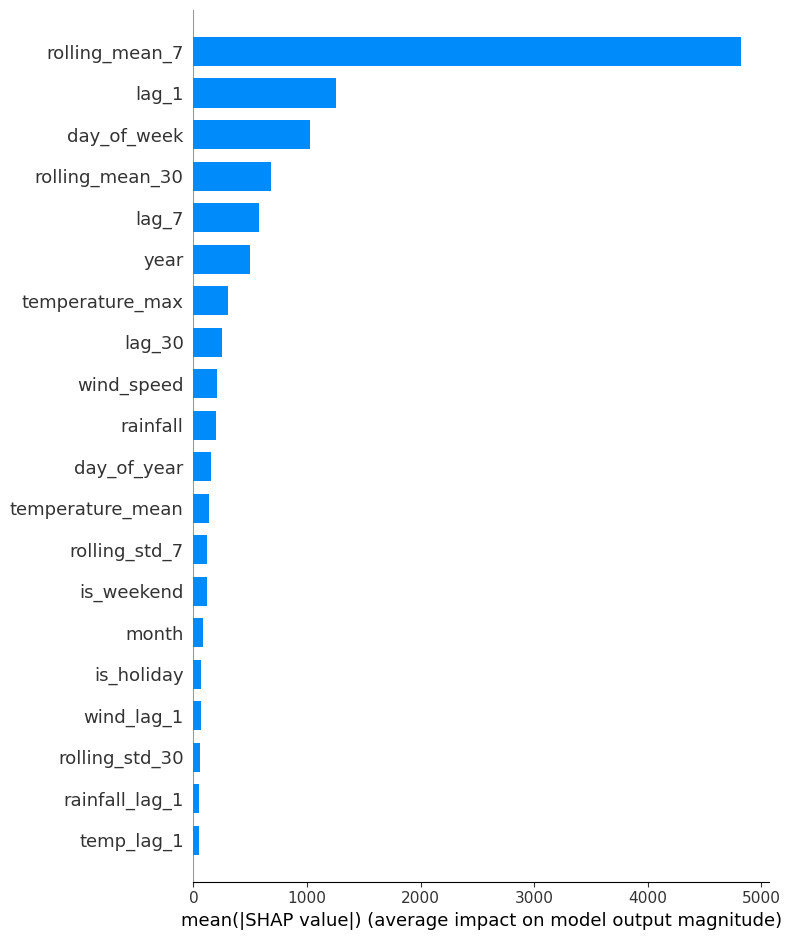

In [10]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.savefig(
    "../reports/figures/shap_v2_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
)

print(importance_df.head(15))

             feature  importance
3     rolling_mean_7    0.437440
4    rolling_mean_30    0.117231
0              lag_1    0.076673
10       day_of_week    0.074209
1              lag_7    0.058069
12        is_weekend    0.052244
13        is_holiday    0.032350
16         is_easter    0.028121
2             lag_30    0.020563
5      rolling_std_7    0.015304
18   temperature_max    0.011226
8              month    0.009435
17  temperature_mean    0.009227
7               year    0.007447
11       day_of_year    0.007339


In [12]:
master_df = pd.read_parquet(
    "../data/processed/uk_energy_master.parquet"
)

print(master_df.columns.tolist())

['SETTLEMENT_DATE', 'SETTLEMENT_PERIOD', 'ND', 'TSD', 'ENGLAND_WALES_DEMAND', 'EMBEDDED_WIND_GENERATION', 'EMBEDDED_WIND_CAPACITY', 'EMBEDDED_SOLAR_GENERATION', 'EMBEDDED_SOLAR_CAPACITY', 'NON_BM_STOR', 'PUMP_STORAGE_PUMPING', 'SCOTTISH_TRANSFER', 'IFA_FLOW', 'IFA2_FLOW', 'BRITNED_FLOW', 'MOYLE_FLOW', 'EAST_WEST_FLOW', 'NEMO_FLOW', 'NSL_FLOW', 'ELECLINK_FLOW', 'VIKING_FLOW', 'GREENLINK_FLOW', 'source_file']


In [13]:
master_df = pd.read_parquet(
    "../data/processed/uk_energy_master.parquet"
)

daily_energy_market = (
    master_df
    .groupby("SETTLEMENT_DATE")
    .agg({
        "EMBEDDED_WIND_GENERATION":"mean",
        "EMBEDDED_SOLAR_GENERATION":"mean",

        "IFA_FLOW":"mean",
        "BRITNED_FLOW":"mean",
        "MOYLE_FLOW":"mean",
        "NEMO_FLOW":"mean",
        "NSL_FLOW":"mean"
    })
    .reset_index()
)

daily_energy_market.head()

,SETTLEMENT_DATE,EMBEDDED_WIND_GENERATION,EMBEDDED_SOLAR_GENERATION,IFA_FLOW,BRITNED_FLOW,MOYLE_FLOW,NEMO_FLOW,NSL_FLOW
0,01-APR-2009,198.229167,0.000000,378.666667,0.000000,-234.479167,0.0,NaN
1,01-APR-2010,1497.312500,0.166667,-510.083333,0.000000,-334.666667,0.0,NaN
2,01-APR-2011,1244.666667,7.333333,556.812500,341.416667,-309.687500,0.0,NaN
3,01-APR-2012,196.104167,223.125000,997.520833,993.229167,-364.416667,0.0,NaN
4,01-APR-2013,900.312500,304.312500,1473.062500,869.416667,-188.708333,0.0,NaN


In [14]:
daily_energy_market.isnull().sum()

SETTLEMENT_DATE                 0
EMBEDDED_WIND_GENERATION     2191
EMBEDDED_SOLAR_GENERATION    2922
IFA_FLOW                        0
BRITNED_FLOW                 2922
MOYLE_FLOW                   1461
NEMO_FLOW                    2922
NSL_FLOW                     6574
dtype: int64

In [15]:
daily_energy_market.corr(
    numeric_only=True
)["EMBEDDED_WIND_GENERATION"].sort_values(
    ascending=False
)

EMBEDDED_WIND_GENERATION     1.000000
MOYLE_FLOW                   0.220620
NEMO_FLOW                    0.175529
EMBEDDED_SOLAR_GENERATION    0.131015
IFA_FLOW                    -0.069364
BRITNED_FLOW                -0.108872
NSL_FLOW                    -0.171084
Name: EMBEDDED_WIND_GENERATION, dtype: float64

In [16]:
daily_energy_market.corr(
    numeric_only=True
)["EMBEDDED_SOLAR_GENERATION"].sort_values(
    ascending=False
)

EMBEDDED_SOLAR_GENERATION    1.000000
NEMO_FLOW                    0.239166
IFA_FLOW                     0.149328
EMBEDDED_WIND_GENERATION     0.131015
NSL_FLOW                     0.125941
MOYLE_FLOW                   0.038088
BRITNED_FLOW                -0.052902
Name: EMBEDDED_SOLAR_GENERATION, dtype: float64

In [17]:
market_df = (
    master_df
    .groupby("SETTLEMENT_DATE")
    .agg({
        "ND":"mean",

        "EMBEDDED_WIND_GENERATION":"mean",
        "EMBEDDED_SOLAR_GENERATION":"mean",

        "IFA_FLOW":"mean",
        "MOYLE_FLOW":"mean"
    })
    .reset_index()
)

market_df.head()

,SETTLEMENT_DATE,ND,EMBEDDED_WIND_GENERATION,EMBEDDED_SOLAR_GENERATION,IFA_FLOW,MOYLE_FLOW
0,01-APR-2009,37913.500000,198.229167,0.000000,378.666667,-234.479167
1,01-APR-2010,38995.750000,1497.312500,0.166667,-510.083333,-334.666667
2,01-APR-2011,36089.416667,1244.666667,7.333333,556.812500,-309.687500
3,01-APR-2012,30626.750000,196.104167,223.125000,997.520833,-364.416667
4,01-APR-2013,35082.541667,900.312500,304.312500,1473.062500,-188.708333


In [18]:
market_df.corr(
    numeric_only=True
)["ND"].sort_values(
    ascending=False
)

ND                           1.000000
MOYLE_FLOW                  -0.083041
IFA_FLOW                    -0.190091
EMBEDDED_WIND_GENERATION    -0.359919
EMBEDDED_SOLAR_GENERATION   -0.729690
Name: ND, dtype: float64

In [19]:
market_df[
    [
        "EMBEDDED_SOLAR_GENERATION",
        "EMBEDDED_WIND_GENERATION"
    ]
].isnull().sum()

EMBEDDED_SOLAR_GENERATION    2922
EMBEDDED_WIND_GENERATION     2191
dtype: int64

In [21]:
market_df[
    market_df["EMBEDDED_SOLAR_GENERATION"].notna()
].head()

,SETTLEMENT_DATE,ND,EMBEDDED_WIND_GENERATION,EMBEDDED_SOLAR_GENERATION,IFA_FLOW,MOYLE_FLOW
0,01-APR-2009,37913.500000,198.229167,0.000000,378.666667,-234.479167
1,01-APR-2010,38995.750000,1497.312500,0.166667,-510.083333,-334.666667
2,01-APR-2011,36089.416667,1244.666667,7.333333,556.812500,-309.687500
3,01-APR-2012,30626.750000,196.104167,223.125000,997.520833,-364.416667
4,01-APR-2013,35082.541667,900.312500,304.312500,1473.062500,-188.708333


In [22]:
market_df[
    market_df["EMBEDDED_WIND_GENERATION"].notna()
].head()

,SETTLEMENT_DATE,ND,EMBEDDED_WIND_GENERATION,EMBEDDED_SOLAR_GENERATION,IFA_FLOW,MOYLE_FLOW
0,01-APR-2009,37913.500000,198.229167,0.000000,378.666667,-234.479167
1,01-APR-2010,38995.750000,1497.312500,0.166667,-510.083333,-334.666667
2,01-APR-2011,36089.416667,1244.666667,7.333333,556.812500,-309.687500
3,01-APR-2012,30626.750000,196.104167,223.125000,997.520833,-364.416667
4,01-APR-2013,35082.541667,900.312500,304.312500,1473.062500,-188.708333


In [24]:
market_df[
    [
        "ND",
        "EMBEDDED_SOLAR_GENERATION",
        "EMBEDDED_WIND_GENERATION"
    ]
].corr()

,ND,EMBEDDED_SOLAR_GENERATION,EMBEDDED_WIND_GENERATION
ND,1.000000,-0.729690,-0.359919
EMBEDDED_SOLAR_GENERATION,-0.729690,1.000000,0.131015
EMBEDDED_WIND_GENERATION,-0.359919,0.131015,1.000000


In [25]:
market_clean = market_df.dropna(
    subset=[
        "EMBEDDED_SOLAR_GENERATION",
        "EMBEDDED_WIND_GENERATION"
    ]
)

print(market_clean.shape)

(6342, 6)


In [26]:
print(
    market_clean["SETTLEMENT_DATE"].min()
)

print(
    market_clean["SETTLEMENT_DATE"].max()
)

01-APR-2009
31-Oct-23


In [27]:
master_df.groupby(
    "SETTLEMENT_DATE"
).agg({
    "EMBEDDED_SOLAR_GENERATION":"mean"
}).describe()

,EMBEDDED_SOLAR_GENERATION
count,6342.000000
mean,986.686633
std,997.318430
min,0.000000
25%,142.942708
50%,669.979167
75%,1623.791667
max,5048.541667


In [28]:
print(market_df["SETTLEMENT_DATE"].dtype)

object


In [29]:
market_df["SETTLEMENT_DATE"] = pd.to_datetime(
    market_df["SETTLEMENT_DATE"],
    format="mixed"
)

In [30]:
print(market_df["SETTLEMENT_DATE"].dtype)

print(market_df["SETTLEMENT_DATE"].min())

print(market_df["SETTLEMENT_DATE"].max())

datetime64[ns]
2001-01-01 00:00:00
2026-05-13 00:00:00


In [31]:
v2_df = pd.read_parquet(
    "../data/processed/energy_features_v2.parquet"
)

print(v2_df["SETTLEMENT_DATE"].dtype)

datetime64[us]


In [32]:
v3_df = v2_df.merge(
    market_df[
        [
            "SETTLEMENT_DATE",
            "EMBEDDED_SOLAR_GENERATION",
            "EMBEDDED_WIND_GENERATION"
        ]
    ],
    on="SETTLEMENT_DATE",
    how="left"
)

print(v3_df.shape)

(9101, 29)


In [33]:
v3_df[
    [
        "EMBEDDED_SOLAR_GENERATION",
        "EMBEDDED_WIND_GENERATION"
    ]
].isnull().sum()

EMBEDDED_SOLAR_GENERATION    2892
EMBEDDED_WIND_GENERATION     2161
dtype: int64

In [34]:
v3_df["solar_available"] = (
    v3_df["EMBEDDED_SOLAR_GENERATION"]
    .notna()
).astype(int)

v3_df["wind_available"] = (
    v3_df["EMBEDDED_WIND_GENERATION"]
    .notna()
).astype(int)

In [35]:
v3_df["solar_available"] = (
    v3_df["EMBEDDED_SOLAR_GENERATION"]
    .notna()
).astype(int)

v3_df["wind_available"] = (
    v3_df["EMBEDDED_WIND_GENERATION"]
    .notna()
).astype(int)

In [36]:
v3_df[
    [
        "EMBEDDED_SOLAR_GENERATION",
        "EMBEDDED_WIND_GENERATION",
        "solar_available",
        "wind_available"
    ]
].isnull().sum()

EMBEDDED_SOLAR_GENERATION    2892
EMBEDDED_WIND_GENERATION     2161
solar_available                 0
wind_available                  0
dtype: int64

In [37]:
v3_df[
    [
        "EMBEDDED_SOLAR_GENERATION",
        "EMBEDDED_WIND_GENERATION"
    ]
].head()

,EMBEDDED_SOLAR_GENERATION,EMBEDDED_WIND_GENERATION
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


In [38]:
v3_df[
    [
        "EMBEDDED_SOLAR_GENERATION",
        "EMBEDDED_WIND_GENERATION"
    ]
].tail()

,EMBEDDED_SOLAR_GENERATION,EMBEDDED_WIND_GENERATION
9096,654.895833,2442.812500
9097,158.354167,1073.604167
9098,168.354167,1120.166667
9099,665.416667,1096.104167
9100,1079.479167,2193.708333


In [39]:
v3_df["EMBEDDED_SOLAR_GENERATION"] = v3_df[
    "EMBEDDED_SOLAR_GENERATION"
].fillna(0)

v3_df["EMBEDDED_WIND_GENERATION"] = v3_df[
    "EMBEDDED_WIND_GENERATION"
].fillna(0)

In [40]:
v3_df[
    [
        "EMBEDDED_SOLAR_GENERATION",
        "EMBEDDED_WIND_GENERATION"
    ]
].isnull().sum()

EMBEDDED_SOLAR_GENERATION    0
EMBEDDED_WIND_GENERATION     0
dtype: int64

In [41]:
v3_df[
    [
        "solar_available",
        "wind_available"
    ]
].value_counts()

solar_available  wind_available
1                1                 6209
0                0                 2161
                 1                  731
Name: count, dtype: int64

In [42]:
v3_df.to_parquet(
    "../data/processed/energy_features_v3.parquet",
    index=False
)

print("energy_features_v3.parquet saved")

energy_features_v3.parquet saved


In [43]:
print(v3_df.shape)

(9101, 31)
